# makemore_batchnorm


## preparation

We'll continue optimizing the code from the previous lesson.

I will use multi-line comments to annotate the optimization notes and code for this lesson.

In [37]:
# import module
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [38]:
# read file
words = open('../names.txt', 'r').read().splitlines()

In [39]:
# utility functions
from string import ascii_lowercase
stoi = {c:i+1 for i, c in enumerate(ascii_lowercase)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}
vocab_size = len(itos)

In [47]:
# build and split the dataset
block_size = 3

def build_dataset(words):  
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])        # 80% training set
Xdev, Ydev = build_dataset(words[n1:n2])    # 10% dev set
Xte, Yte = build_dataset(words[n2:])        # 10% test set

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [ ]:
# MLP
g = torch.Generator().manual_seed(2147483647)

emb_dim = 10    # dimension of embedding vectors
ns_num_h = 200    # the number of neurons in hidden layer

"""
Fixing the Initial Loss

Scale down output layer weights/biases near 0 to fix the artificially high initial loss.
Without this, standard normal init causes extreme logits (loss ~27). 
Scaling drops the initial loss to ~3.3 (since we have 27 characters, a uniform distribution 
yields an expected initial loss of exactly -log(1/27) ≈ 3.3). This saves early epochs 
from merely squashing weights and allows the model to focus on meaningful learning immediately.

Note on leaf vs. non-leaf nodes:
Leaf nodes have gradients (`.grad`) but no gradient function (.grad_fn).
Non-leaf nodes have a gradient function but do not retain gradients. 
Therefore, we update parameters via `tensor.data` to perform in-place operations 
without breaking the autograd computation graph.
"""
C = torch.randn((vocab_size, emb_dim),             generator=g, requires_grad=True)
W1 = torch.randn((block_size * emb_dim, ns_num_h), generator=g, requires_grad=True)
B1 = torch.randn(ns_num_h,                         generator=g, requires_grad=True)
W2 = torch.randn((ns_num_h, vocab_size),           generator=g, requires_grad=True)
W2.data *= 0.01
B2 = torch.randn(vocab_size,                       generator=g, requires_grad=True)
B2.data *= 0
parameters = [C, W1, B1, W2, B2]

print(sum(p.numel() for p in parameters))

11897


In [51]:
# use training set to train model
max_steps = 200000
batch_size = 32
lossi = []

for k in range(max_steps):
    
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass
    emb = C[Xtr[ix]]
    hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
    logits = hl @ W2 + B2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += p.grad * -(lr := 0.1 if k < 100000 else 0.01)

    # monitor
    if k % 10000 == 0:
        print(f'{k:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.item())

      0/ 200000: 3.3046
  10000/ 200000: 2.6073
  20000/ 200000: 2.0953
  30000/ 200000: 1.9144
  40000/ 200000: 2.5296
  50000/ 200000: 1.9599
  60000/ 200000: 2.2124
  70000/ 200000: 2.2408
  80000/ 200000: 2.1750
  90000/ 200000: 1.6496
 100000/ 200000: 1.7009
 110000/ 200000: 1.9936
 120000/ 200000: 2.5043
 130000/ 200000: 2.3610
 140000/ 200000: 2.1180
 150000/ 200000: 2.0210
 160000/ 200000: 1.9186
 170000/ 200000: 2.4077
 180000/ 200000: 1.8545
 190000/ 200000: 2.2493


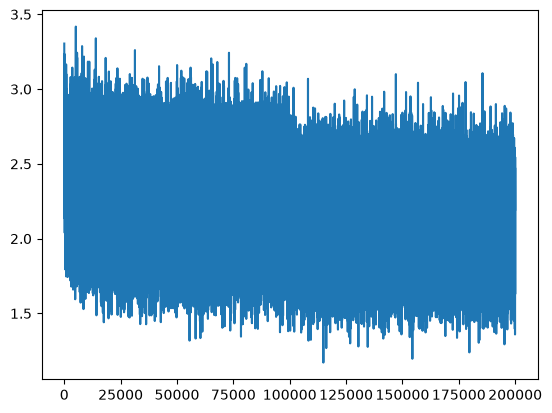

In [52]:
plt.plot(lossi)

In [53]:
# evaluate the model and adjust hyperparameters
@torch.no_grad()
def splits_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x]
    hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
    logits = hl @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(f"{split}: loss: {loss}")
    return loss

tr_loss = splits_loss('train')
dev_loss = splits_loss('dev')

train: loss: 2.068631410598755
dev: loss: 2.127005100250244


In [31]:
# sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    outs = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        hl = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + B1)
        logits = hl @ W2 + B2
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g)
        outs.append(itos[ix.item()])
        context = context[1:] + [ix]
        if ix == 0: break
    print(''.join(outs))

carmah.
amelle.
khy.
mili.
taty.
halaysie.
mahnee.
den.
art.
areei.
